# Value Function Approximation

Following various segments in Part 2 of *Reinforcement Learning* (edition 2) by Andrew Barto and Richard S. Sutton

### Setup

In [1]:
import math
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
from functools import partial

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation
from typing import Callable, Any, Optional
from IPython.display import HTML

from util.envs import GridMazeEnv, Action, State

### Gridworld

In [2]:
maze_grid = np.array([
    [0, 0, 0, 0, 0, 0, 0, 1, 3],
    [0, 0, 1, 0, 0, 0, 0, 1, 0],
    [2, 0, 1, 0, 0, 0, 0, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0],
])

maze_env = GridMazeEnv(maze_grid)
maze_env

[[□ □ □ □ □ □ □ ■ G]
 [□ □ ■ □ □ □ □ ■ □]
 [S □ ■ □ □ □ □ ■ □]
 [□ □ ■ □ □ □ □ □ □]
 [□ □ □ □ □ □ □ □ □]
 [□ □ □ □ □ ■ □ □ □]]

In [3]:
def get_state_features_normalized(s: tuple[int, int], grid_shape: tuple[int, ...]) -> torch.Tensor:
    """Return normalized grid coords."""
    s_features = (s[0] / (grid_shape[0] - 1), s[1] / (grid_shape[1] - 1))
    return torch.Tensor(s_features)

def get_state_features_one_hot(s: tuple[int, int], grid_shape: tuple[int, ...]) -> torch.Tensor:
    """
    One-hot encoding of grid state. Equivalent to tabular representation.
    """
    H, W = grid_shape
    idx = s[0] * W + s[1]

    x = torch.zeros(H * W, dtype=torch.float32)
    x[idx] = 1.0
    return x

### Linear Function Approximation

In [5]:
class Q_VFA_Linear(nn.Module):
    def __init__(self, state_dim: int, action_dim):
        super().__init__()
        self.w = nn.Linear(state_dim, action_dim, bias=False) # taking in state feature vector, spitting out Q-value for each action
    
    def forward(self, x: torch.Tensor):
        return self.w(x)

In [ ]:
def pi_epsilon_greedy(s: tuple[int, int], Q_pi: Q_VFA_Linear, epsilon: float, grid_shape: tuple[int, ...], state_features_method: Callable) -> int:
    p = np.random.random()

    if p < epsilon: # explore
        return int(np.random.randint(Q_pi.w.weight.shape[0]))
    return int(np.argmax(Q_pi(state_features_method(s, grid_shape)).detach().numpy())) # exploit

In [7]:
q_hat = Q_VFA_Linear(get_state_features_one_hot(maze_env.goal_position, maze_env.grid.shape).shape[0], maze_env.action_set.__len__())
q_hat

Q_VFA_Linear(
  (w): Linear(in_features=54, out_features=4, bias=False)
)

In [8]:
q_hat.w.weight

Parameter containing:
tensor([[ 4.1558e-02,  6.3551e-02, -6.4044e-02,  1.1278e-01, -6.5700e-02,
          1.0391e-02, -6.1423e-02, -3.2566e-02, -5.9359e-02,  1.1539e-01,
          1.0503e-01, -8.8013e-02, -1.1290e-01, -1.2880e-01,  1.9625e-02,
          2.1695e-02,  8.2716e-02, -6.4005e-02,  5.6970e-02, -8.5720e-02,
          1.2314e-01, -1.2777e-02,  7.5729e-02,  6.6048e-02,  1.0308e-01,
         -1.3051e-01,  7.6513e-02, -9.1849e-02, -1.1033e-01, -1.3298e-01,
          9.9083e-03,  4.9032e-02,  5.2593e-02,  3.1929e-02, -7.3610e-03,
         -7.4867e-02, -1.3439e-01, -9.7714e-02,  1.1740e-01, -1.0599e-01,
          8.8027e-02,  2.9633e-02, -1.6830e-02,  1.0170e-02, -1.1824e-01,
          3.2358e-02,  1.2524e-01,  3.8511e-02,  9.1695e-02, -7.9212e-02,
         -8.5080e-02,  6.4040e-02, -1.2520e-01, -3.7993e-02],
        [-4.0685e-02, -1.1359e-01,  1.0506e-02, -6.3596e-02, -8.3238e-02,
         -3.0518e-02,  2.4612e-02, -3.2642e-02, -1.0203e-01,  9.1160e-02,
          7.4192e-03,  1.315

#### Q-Learning / TD-0

In [9]:
def run_QLearning_VFA(
    maze_env: GridMazeEnv, 
    gamma: float, alpha: float, 
    epsilon_start: float, epsilon_min: float, epsilon_decay: float,
    num_epochs: int, warmup_epochs: int, max_steps: int,
    state_features_method: Callable,
    ) -> tuple[Q_VFA_Linear, dict]:

    grid_shape = maze_env.grid.shape
    q_hat = Q_VFA_Linear(
        state_features_method(maze_env.goal_position, grid_shape).shape[0], 
        maze_env.action_set.__len__()
        )
    optimizer = torch.optim.SGD(q_hat.parameters(), lr=alpha)
    pbar = tqdm(range(num_epochs), desc="Q-Learning")
    metrics = {
        "episode_lengths": [],
        "episode_returns": []
    }

    successes = 0
    for ep_idx in pbar:

        # --- epsilon schedule ---
        if ep_idx < warmup_epochs:
            epsilon = epsilon_start
        else:
            epsilon = max(epsilon_min, epsilon_start * (epsilon_decay ** (ep_idx - warmup_epochs)))

        # --- initial state ---
        s = maze_env.reset()    

        # --- intra-episode loop ---
        episode_steps = 0
        episode_return = 0.0
        for step in range(max_steps):
            phi_s = state_features_method(s, grid_shape) # Extract state features for s

            # --- select action and step ---
            a = pi_epsilon_greedy(s, q_hat, epsilon, grid_shape, state_features_method)
            r, s_prime, done = maze_env.step(a)

            # --- Reward adjustment for maze ---
            if done:
                r = 1.0 # Goal reward
            else:
                r = -0.01 # Step penalty

            # --- s' features and a' for SARSA ---
            phi_sp = state_features_method(s_prime, grid_shape) # Extract state features for s'
            a_prime = torch.argmax(q_hat(phi_sp)).item() # Greedy action (off-policy) - Q-Learning

            # --- value function update ---
            prediction = q_hat(phi_s)[a] # Q(s, a)
            with torch.no_grad(): # using no_grad here to *ensure* that the target's gradients will not be used - only the prediction
                q_next = 0.0 if done else q_hat(phi_sp)[a_prime] # Q(s', a')
                target = r + gamma * q_next # bootstrapping target: r + γ * Q(s', a')
            loss = 0.5 * ((target - prediction) ** 2) # error term: 0.5 * [r + γ * Q(s', a') - Q(s, a)] ^ 2
            # Note that the 0.5 is added here to balance the fact that the derivative w.r.t. the loss will transform the square exponent
            # into a *2 multiplier upon calling optimizer.step()

            optimizer.zero_grad()
            loss.backward() # compute gradients backwards from loss (error term)
            optimizer.step() # update: w <- w + α * [r + γ * Q(s', a') - Q(s', a')] * ∇Q(s, a)
            # Note that α (alpha) here comes from the optimizer itself (lr)

            # --- housekeeping ---
            s = s_prime
            episode_steps = step + 1
            episode_return += r
            if done:
                successes += 1
                break
        
        # --- update metrics & pbar ---
        metrics["episode_lengths"].append(episode_steps)
        metrics["episode_returns"].append(episode_return)
        pbar.set_postfix(
            successes=f"{successes}/{ep_idx + 1}",
            steps=step + 1,
            epsilon=f"{epsilon:.3f}",
        )
    
    # --- return ---
    return q_hat, metrics

In [15]:
alpha = 5e-1
gamma = 0.9
epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995
num_epochs = 1000
warmup_epochs = 50
max_steps = 150
state_feature_method: Callable = get_state_features_one_hot

q_hat, metrics = run_QLearning_VFA(maze_env, gamma, alpha, epsilon_start, epsilon_min, epsilon_decay, num_epochs, warmup_epochs, max_steps, state_feature_method)

Q-Learning: 100%|██████████| 1000/1000 [00:13<00:00, 72.43it/s, epsilon=0.050, steps=16, successes=934/1000]


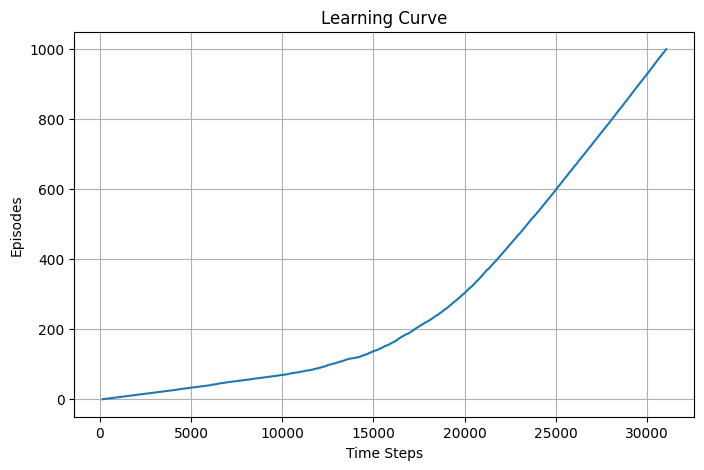

In [16]:
maze_env.plot_time_steps_per_episode(metrics["episode_lengths"])

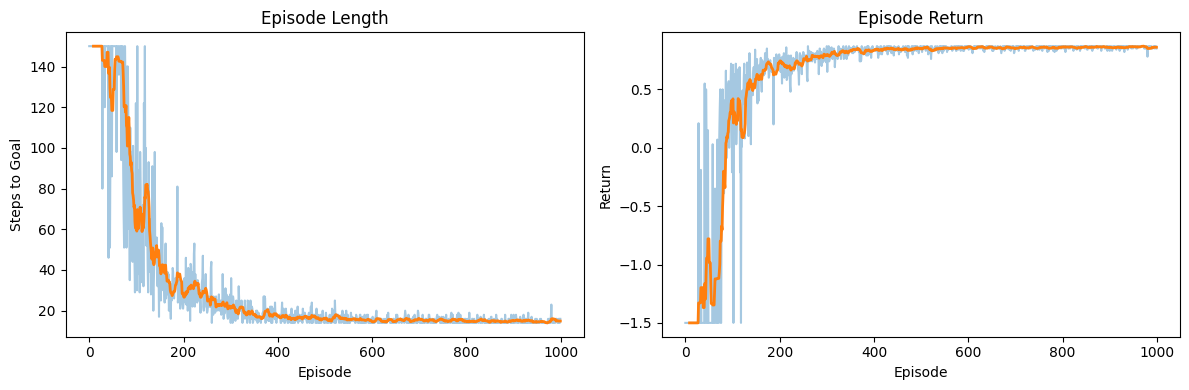

In [17]:
maze_env.plot_training_metrics(metrics["episode_lengths"], metrics["episode_returns"])

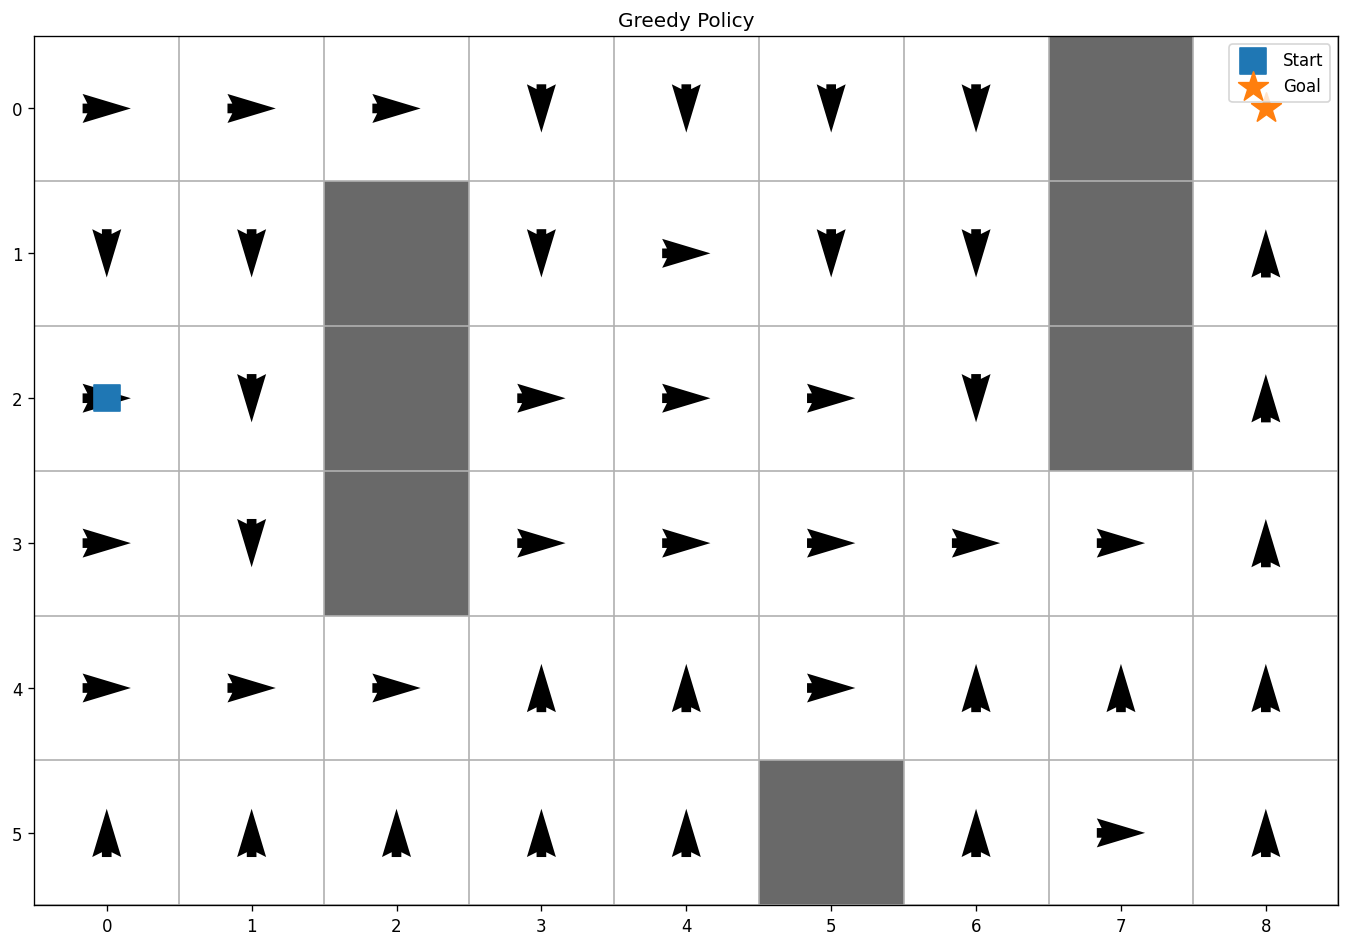

In [18]:
maze_env.plot_policy(
    q_hat, 
    maze_env.action_set, 
    get_features=partial(state_feature_method, grid_shape=maze_env.grid.shape)
    )

In [19]:
maze_env.animate_episode_with_trail(
    q_hat, 
    maze_env.action_set, 
    get_features=partial(state_feature_method, grid_shape=maze_env.grid.shape),
    starting_state=(2, 0)
    )

#### Monte-Carlo

In [20]:
def run_monte_carlo_VFA(
    maze_env: GridMazeEnv, 
    gamma: float, alpha: float, 
    epsilon_start: float, epsilon_min: float, epsilon_decay: float,
    num_epochs: int, warmup_epochs: int, max_steps: int,
    state_features_method: Callable,
    ) -> tuple[Q_VFA_Linear, dict]:

    grid_shape = maze_env.grid.shape
    q_hat = Q_VFA_Linear(
        state_features_method(maze_env.goal_position, grid_shape).shape[0], 
        maze_env.action_set.__len__()
        )
    optimizer = torch.optim.SGD(q_hat.parameters(), lr=alpha)
    pbar = tqdm(range(num_epochs), desc="Monte Carlo")
    metrics = {
        "episode_lengths": [],
        "episode_returns": []
    }

    successes = 0
    episode_return = 0.0
    for ep_idx in pbar:

        # --- epsilon schedule ---
        if ep_idx < warmup_epochs:
            epsilon = epsilon_start
        else:
            epsilon = max(epsilon_min, epsilon_start * (epsilon_decay ** (ep_idx - warmup_epochs)))

        # --- record episode ---
        S = []
        A = []
        R = []

        # --- initial state ---
        S.append(maze_env.reset())

        # --- episode rollout ---
        episode_steps = 0
        for step in range(max_steps):
            # --- select action and step ---
            s = S[-1]
            a = pi_epsilon_greedy(s, q_hat, epsilon, grid_shape, state_features_method)
            r, s_prime, done = maze_env.step(a)

            # --- Reward adjustment for maze ---
            if done:
                r = 1.0 # Goal reward
            else:
                r = -0.01 # Step penalty

            # --- store step ---
            A.append(a)
            R.append(r)
            S.append(s_prime)

            # --- housekeeping ---
            episode_steps = step + 1
            episode_return += r
            if done:
                successes += 1
                break

        # --- monte-carlo update ---
        losses = [] # aggregate losses and update via batch (instead of individually)
        G = 0.0
        for t in reversed(range(episode_steps)): # calculate loss at each state (every-visit MC)
            G = R[t] + gamma * G

            x_s: torch.Tensor = state_features_method(S[t], grid_shape) # state featuers
            q_sa = q_hat(x_s)[A[t]] # prediction
            target = torch.tensor(G, dtype=q_sa.dtype, device=q_sa.device)
            losses.append((target - q_sa) ** 2) # loss = (target - prediction) ^ 2
            losses.append((G - q_sa) ** 2) 
            
        loss = torch.stack(losses).sum() # Batch update - least squares; NOTE: Using sum instead of mean here
        # to compensate for the significantly lower number of updates. Might compensate for discrepancy and interaction
        # with alpha (lr)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # --- update metrics & pbar ---
        metrics["episode_lengths"].append(episode_steps)
        metrics["episode_returns"].append(episode_return)
        pbar.set_postfix(
            successes=f"{successes}/{ep_idx + 1}",
            steps=step + 1,
            epsilon=f"{epsilon:.3f}",
            G=f"{G:.5f}"
        )
    
    # --- return ---
    return q_hat, metrics

In [21]:
alpha = 1e-3
gamma = 0.99
epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.999   
num_epochs = 5000
warmup_epochs = 50
max_steps = 500
state_feature_method: Callable = get_state_features_one_hot

q_hat, metrics = run_monte_carlo_VFA(maze_env, gamma, alpha, epsilon_start, epsilon_min, epsilon_decay, num_epochs, warmup_epochs, max_steps, state_feature_method)

Monte Carlo: 100%|██████████| 5000/5000 [00:49<00:00, 100.97it/s, G=0.72012, epsilon=0.050, steps=16, successes=4921/5000]  


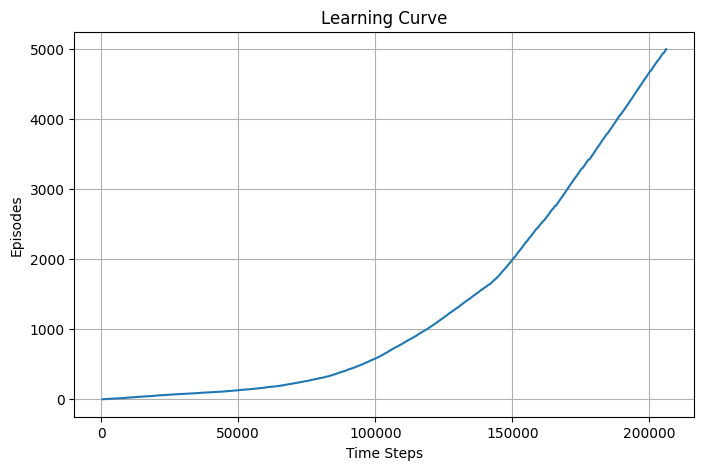

In [22]:
maze_env.plot_time_steps_per_episode(metrics["episode_lengths"])

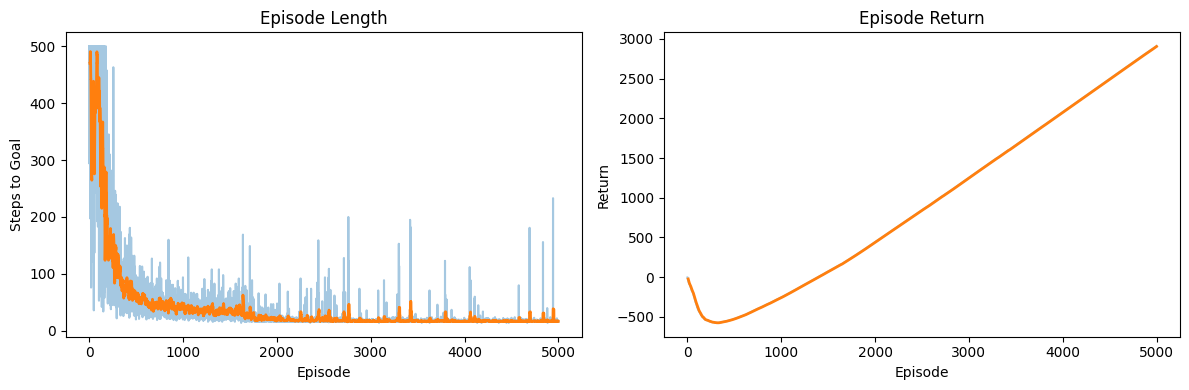

In [23]:
maze_env.plot_training_metrics(metrics["episode_lengths"], metrics["episode_returns"])

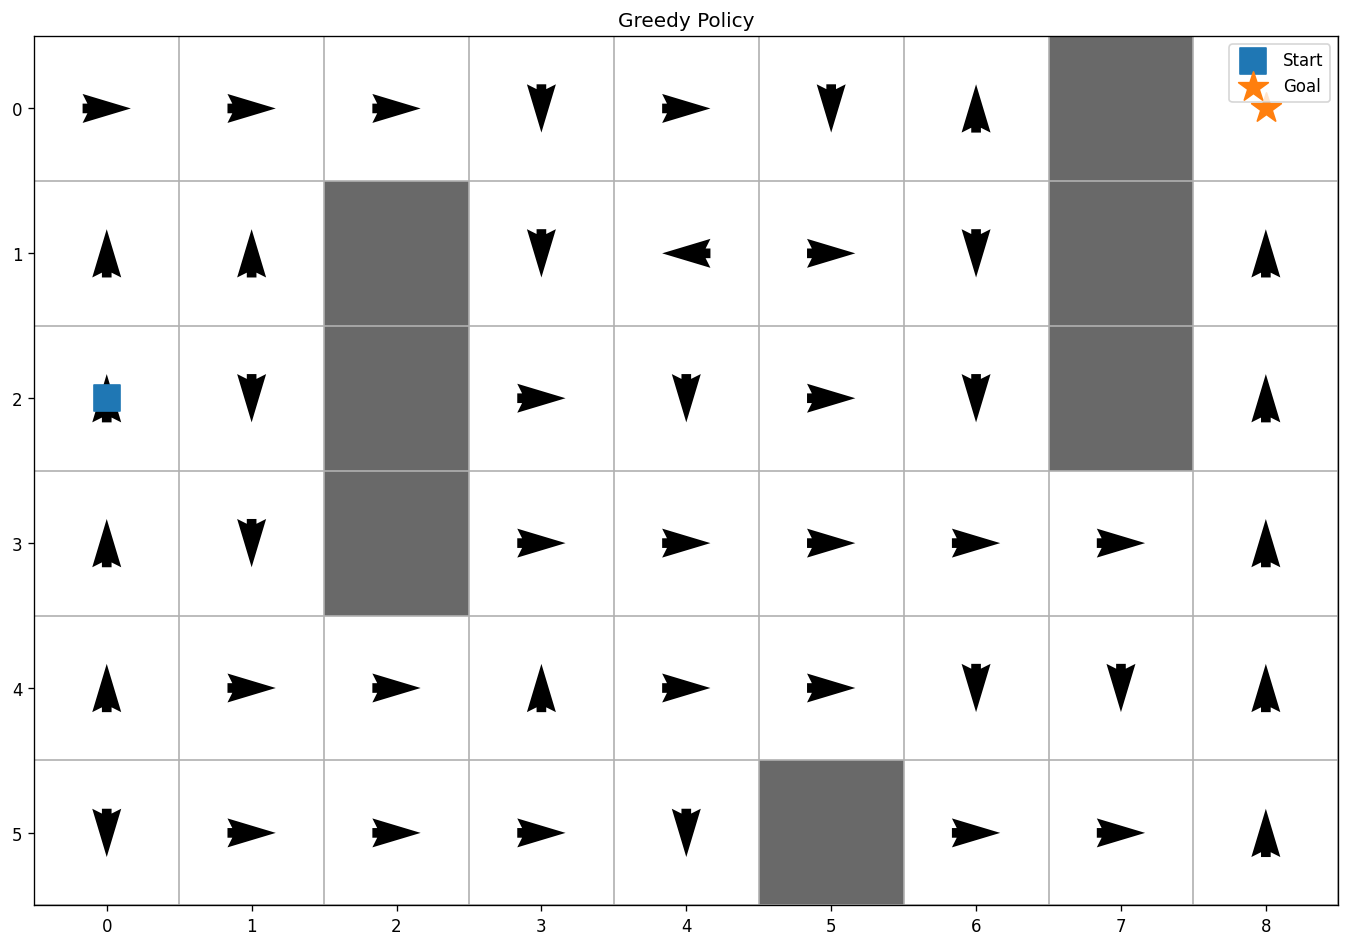

In [24]:
maze_env.plot_policy(
    q_hat, 
    maze_env.action_set, 
    get_features=partial(state_feature_method, grid_shape=maze_env.grid.shape)
    )

In [25]:
maze_env.animate_episode_with_trail(
    q_hat, 
    maze_env.action_set, 
    get_features=partial(state_feature_method, grid_shape=maze_env.grid.shape),
    starting_state=(2, 0)
    )

### Feature Representation - Tile Coding

Following Sutton and Barto's Tile Coding chapter - Chapter *9.5.4*, starting at page *217*

In [26]:
class TileCoder2D:
    def __init__(self, num_tilings: int = 4, tile_size: int = 2):
        """
        2D tile coder with symmetrical offsets.

        Args:
            num_tilings: The number of overlapping grids.
            tile_size: The width/height of each tile in grid cells.
        """
        self.num_tilings = num_tilings
        self.tile_size = tile_size

    def __call__(self, s: tuple[int, int], grid_shape: tuple[int, ...]) -> torch.Tensor:
        """
        Returns a binary feature vector representing the tile-coded state.
        Matches the signature of your previous feature methods.
        """
        H, W = grid_shape
        x, y = s
        
        # Calculate grid dimensions for a single tiling. 
        # We add 1 to accommodate the maximum possible offset pushing coordinates into a new tile boundary.
        tiles_per_row = math.ceil(H / self.tile_size) + 1
        tiles_per_col = math.ceil(W / self.tile_size) + 1
        tiles_per_tiling = tiles_per_row * tiles_per_col
        
        # Initialize the sparse binary feature vector
        total_features = self.num_tilings * tiles_per_tiling
        features = torch.zeros(total_features, dtype=torch.float32)
        
        for i in range(self.num_tilings):
            # Calculate the uniform offset for this specific tiling
            offset = (i / self.num_tilings) * self.tile_size
            
            # Map the continuous/absolute coordinate to the discrete tile index
            tile_x = int((x + offset) // self.tile_size)
            tile_y = int((y + offset) // self.tile_size)
            
            # Flatten the 2D tile index into a 1D index for this specific tiling
            local_idx = tile_x * tiles_per_col + tile_y
            
            # Shift the index to the correct block in the global feature vector
            global_idx = (i * tiles_per_tiling) + local_idx
            
            features[global_idx] = 1.0
            
        return features

In [27]:
tile_coder = TileCoder2D(num_tilings=4, tile_size=2)

In [28]:
tile_coder(s=(0, 0), grid_shape=maze_env.grid.shape) # out: flattened vector representing state presence in every separate tiling

tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.])

Q-Learning with Tile Coding

In [29]:
alpha = 5e-1 / tile_coder.num_tilings # Scaling lr / step size to be relatively the same as the one-hot scenario
# In the one-hot scenario, the feature-vector sum was 1 (one-hot - all zeros and one 1). In the tile coder scenario,
# the feature-vector sum is equal to num_tilings - acting as a multiplier to the lr
gamma = 0.9
epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995
num_epochs = 1000
warmup_epochs = 50
max_steps = 150
state_feature_method: Callable = tile_coder

q_hat, metrics = run_QLearning_VFA(maze_env, gamma, alpha, epsilon_start, epsilon_min, epsilon_decay, num_epochs, warmup_epochs, max_steps, state_feature_method)

Q-Learning: 100%|██████████| 1000/1000 [00:15<00:00, 65.06it/s, epsilon=0.050, steps=14, successes=927/1000]


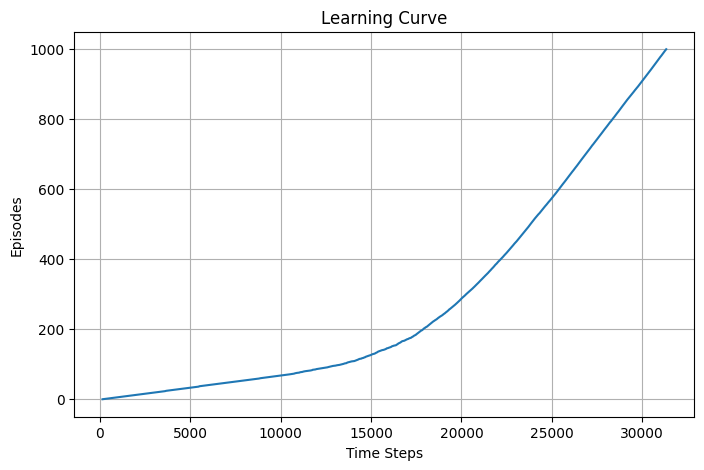

In [30]:
maze_env.plot_time_steps_per_episode(metrics["episode_lengths"])

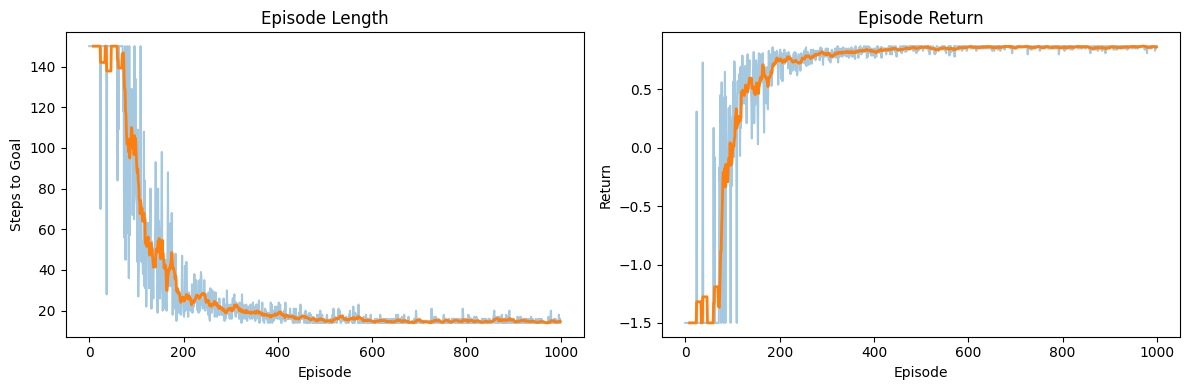

In [31]:
maze_env.plot_training_metrics(metrics["episode_lengths"], metrics["episode_returns"])

Monte Carlo with Tile Coding

In [32]:
alpha = 1e-3
gamma = 0.99
epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.999   
num_epochs = 5000
warmup_epochs = 50
max_steps = 500
state_feature_method: Callable = tile_coder

q_hat, metrics = run_monte_carlo_VFA(maze_env, gamma, alpha, epsilon_start, epsilon_min, epsilon_decay, num_epochs, warmup_epochs, max_steps, state_feature_method)

Monte Carlo: 100%|██████████| 5000/5000 [00:54<00:00, 91.38it/s, G=0.68589, epsilon=0.050, steps=18, successes=4929/5000]   


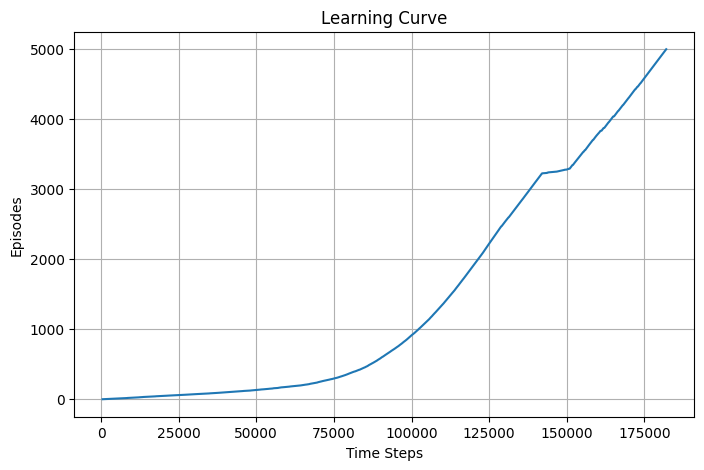

In [33]:
maze_env.plot_time_steps_per_episode(metrics["episode_lengths"])

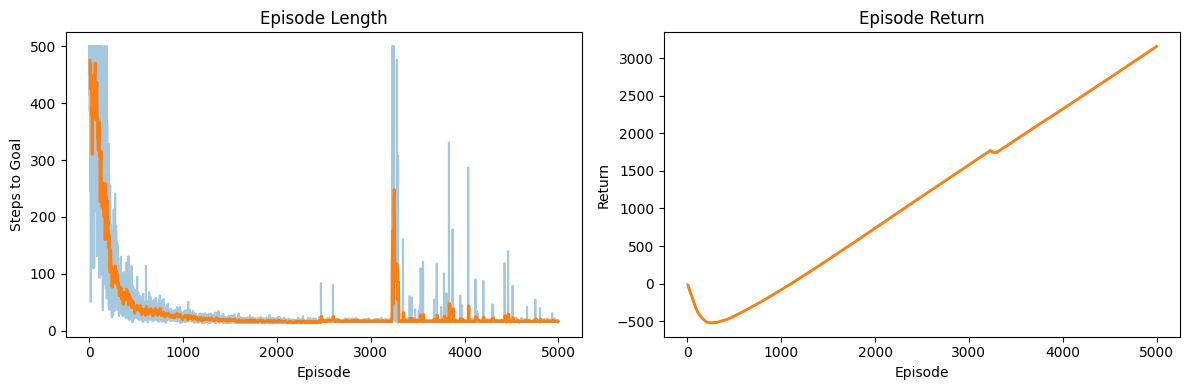

In [34]:
maze_env.plot_training_metrics(metrics["episode_lengths"], metrics["episode_returns"])

### Non-Linear: Neural Networks

In [18]:
class Q_VFA_MLP(nn.Module):
    def __init__(self, state_dim: int, action_dim, hidden_dims: tuple[int, ...]):
        super().__init__()
        layers = [
            nn.Linear(state_dim, hidden_dims[0]), nn.ReLU(),
            ]
        for i in range(len(hidden_dims)-1):
            layers.append(nn.Linear(hidden_dims[i], hidden_dims[i+1]))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_dims[-1], action_dim)) # No activation - value function is unbounded and can be negative
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor):
        return self.network(x)
    
    def pi_epsilon_greedy(self, s: tuple[int, int], epsilon: float, grid_shape: tuple[int, ...], state_features_method: Callable) -> int:
        p = np.random.random()

        if p < epsilon: # explore
            return int(np.random.randint(self.network[-1].weight.shape[0]))
        return int(np.argmax(self(state_features_method(s, grid_shape)).detach().numpy())) # exploit

In [24]:
def run_QLearning_VFA_MLP(
    maze_env: GridMazeEnv, 
    gamma: float, alpha: float, 
    epsilon_start: float, epsilon_min: float, epsilon_decay: float,
    num_epochs: int, warmup_epochs: int, max_steps: int,
    state_features_method: Callable,
    vfa_num_hiddle_layers: int
    ) -> tuple[Q_VFA_MLP, dict]:

    grid_shape = maze_env.grid.shape
    num_actions = maze_env.action_set.__len__()
    q_hat = Q_VFA_MLP(
        state_features_method(maze_env.goal_position, grid_shape).shape[0], 
        num_actions,
        (num_actions * 2,) * vfa_num_hiddle_layers
        )
    optimizer = torch.optim.Adam(q_hat.parameters(), lr=alpha)
    pbar = tqdm(range(num_epochs), desc="Q-Learning")
    metrics = {
        "episode_lengths": [],
        "episode_returns": []
    }

    successes = 0
    for ep_idx in pbar:

        # --- epsilon schedule ---
        if ep_idx < warmup_epochs:
            epsilon = epsilon_start
        else:
            epsilon = max(epsilon_min, epsilon_start * (epsilon_decay ** (ep_idx - warmup_epochs)))

        # --- initial state ---
        s = maze_env.reset()    

        # --- intra-episode loop ---
        episode_steps = 0
        episode_return = 0.0
        for step in range(max_steps):
            phi_s = state_features_method(s, grid_shape) # Extract state features for s

            # --- select action and step ---
            a = q_hat.pi_epsilon_greedy(s, epsilon, grid_shape, state_features_method)
            r, s_prime, done = maze_env.step(a)

            # --- Reward adjustment for maze ---
            if done:
                r = 1.0 # Goal reward
            else:
                r = -0.01 # Step penalty

            # --- s' features and a' for SARSA ---
            phi_sp = state_features_method(s_prime, grid_shape) # Extract state features for s'
            a_prime = torch.argmax(q_hat(phi_sp)).item() # Greedy action (off-policy) - Q-Learning

            # --- value function update ---
            prediction = q_hat(phi_s)[a] # Q(s, a)
            with torch.no_grad(): # using no_grad here to *ensure* that the target's gradients will not be used - only the prediction
                q_next = 0.0 if done else q_hat(phi_sp)[a_prime] # Q(s', a')
                target = r + gamma * q_next # bootstrapping target: r + γ * Q(s', a')
            loss = 0.5 * ((target - prediction) ** 2) # error term: 0.5 * [r + γ * Q(s', a') - Q(s, a)] ^ 2
            # Note that the 0.5 is added here to balance the fact that the derivative w.r.t. the loss will transform the square exponent
            # into a *2 multiplier upon calling optimizer.step()

            optimizer.zero_grad()
            loss.backward() # compute gradients backwards from loss (error term)
            optimizer.step() # update: w <- w + α * [r + γ * Q(s', a') - Q(s', a')] * ∇Q(s, a)
            # Note that α (alpha) here comes from the optimizer itself (lr)

            # --- housekeeping ---
            s = s_prime
            episode_steps = step + 1
            episode_return += r
            if done:
                successes += 1
                break
        
        # --- update metrics & pbar ---
        metrics["episode_lengths"].append(episode_steps)
        metrics["episode_returns"].append(episode_return)
        pbar.set_postfix(
            successes=f"{successes}/{ep_idx + 1}",
            steps=step + 1,
            epsilon=f"{epsilon:.3f}",
        )
    
    # --- return ---
    return q_hat, metrics

In [28]:
tile_coder = TileCoder2D(num_tilings=4, tile_size=2)

alpha = 6e-5
gamma = 0.9
epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995
num_epochs = 1000
warmup_epochs = 50
max_steps = 150
state_feature_method: Callable = tile_coder
num_hidden_layers = 1

q_hat, metrics = run_QLearning_VFA_MLP(maze_env, gamma, alpha, epsilon_start, epsilon_min, epsilon_decay, num_epochs, warmup_epochs, max_steps, state_feature_method, num_hidden_layers)

Q-Learning: 100%|██████████| 1000/1000 [00:49<00:00, 20.08it/s, epsilon=0.050, steps=14, successes=819/1000]


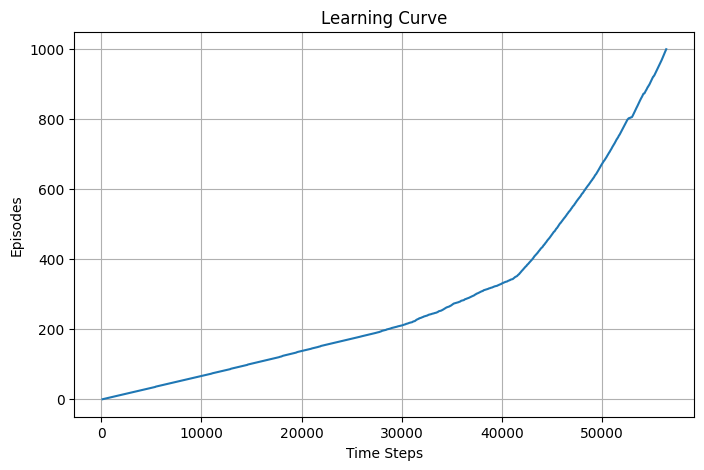

In [29]:
maze_env.plot_time_steps_per_episode(metrics["episode_lengths"])

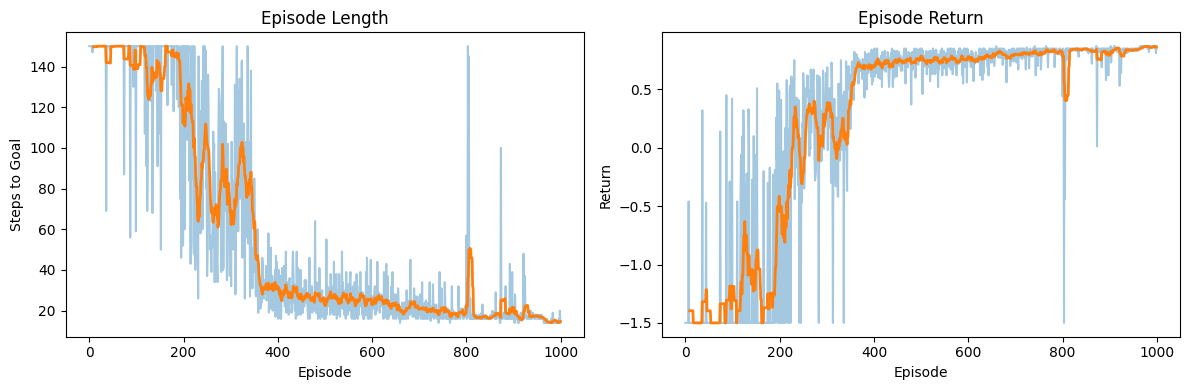

In [30]:
maze_env.plot_training_metrics(metrics["episode_lengths"], metrics["episode_returns"])

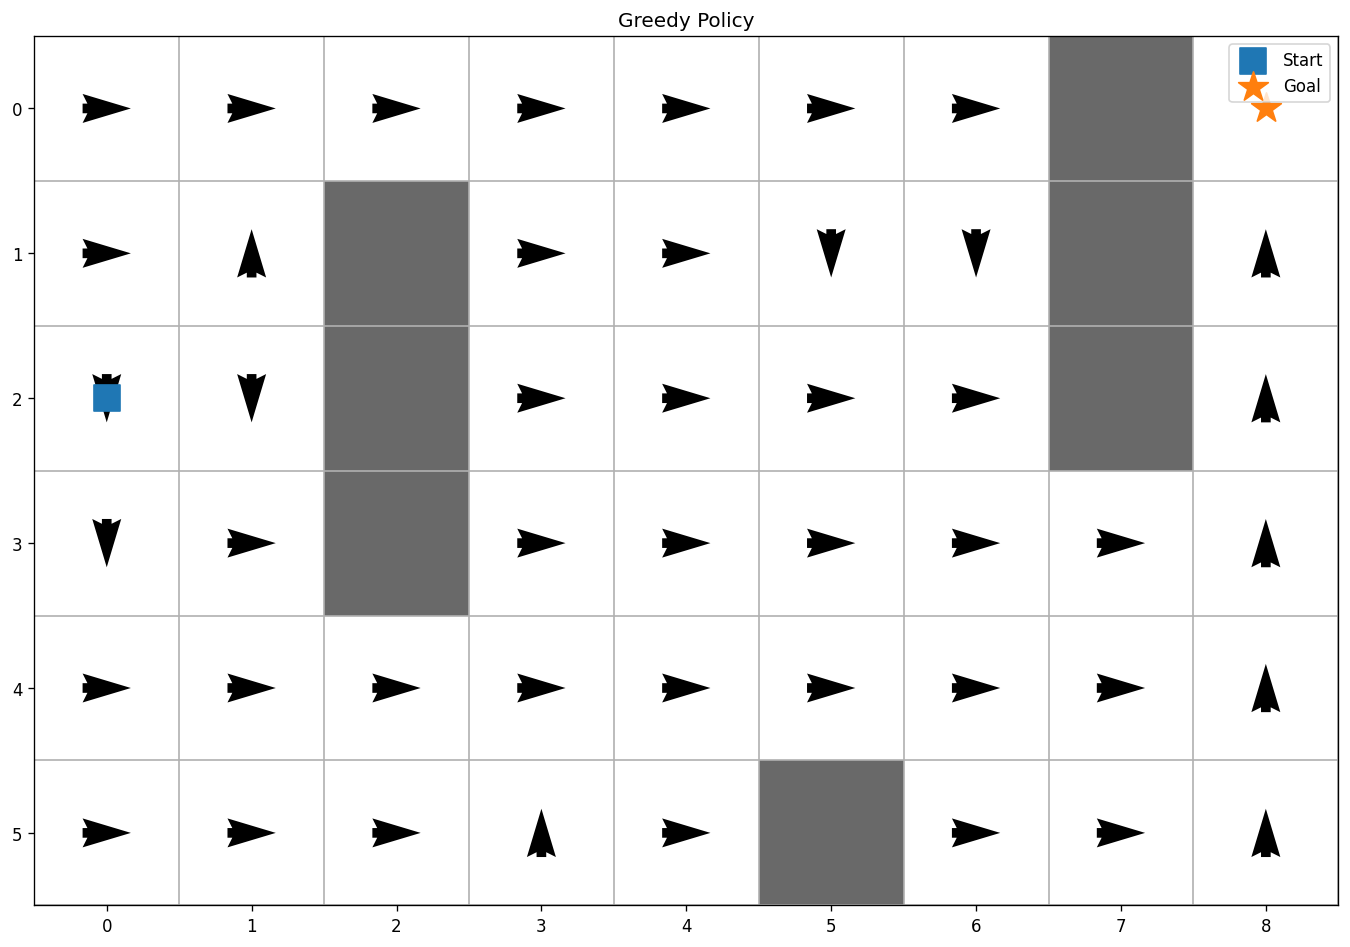

In [31]:
maze_env.plot_policy(
    q_hat, 
    maze_env.action_set, 
    get_features=partial(state_feature_method, grid_shape=maze_env.grid.shape)
    )

In [ ]:
# TO DO: Generalized from ego-centric state view / using 'image' of surrounding tiles? FOV?